In [1]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [2]:
from tqdm.notebook import tqdm
for i in tqdm(range(5)):
    pass


  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
df = pd.read_csv("../data/train_processed.csv", parse_dates=["Date"])
print(df.shape)
df.head()


(1017209, 28)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,Day,WeekOfYear,DayOfYear,IsWeekend,Sales_lag_7,Sales_lag_30,Sales_roll_mean_7,Sales_roll_mean_30
0,1,2,2013-01-01,0,0,0,0,1,1,2,...,2013,1,1,1,1,0,0.0,0.0,0.0,0.0
1,1,3,2013-01-02,5530,668,1,0,0,1,2,...,2013,1,2,1,2,0,0.0,0.0,0.0,0.0
2,1,4,2013-01-03,4327,578,1,0,0,1,2,...,2013,1,3,1,3,0,0.0,0.0,0.0,0.0
3,1,5,2013-01-04,4486,619,1,0,0,1,2,...,2013,1,4,1,4,0,0.0,0.0,0.0,0.0
4,1,6,2013-01-05,4997,635,1,0,0,1,2,...,2013,1,5,1,5,1,0.0,0.0,0.0,0.0


In [4]:
store_id = 1
store_df = df[df["Store"] == store_id].copy()
store_df = store_df[store_df["Open"] == 1]   # ignore closed days


In [5]:
prophet_df = store_df.rename(columns={"Date": "ds", "Sales": "y"})
prophet_df = prophet_df[["ds", "y"]]
prophet_df.head()


,ds,y
1,2013-01-02,5530
2,2013-01-03,4327
3,2013-01-04,4486
4,2013-01-05,4997
6,2013-01-07,7176


In [6]:
train = prophet_df.iloc[:-42]
test = prophet_df.iloc[-42:]


In [7]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.5
)
model.fit(train)


15:16:43 - cmdstanpy - INFO - Chain [1] start processing
15:16:43 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(periods=42)
forecast = model.predict(future)


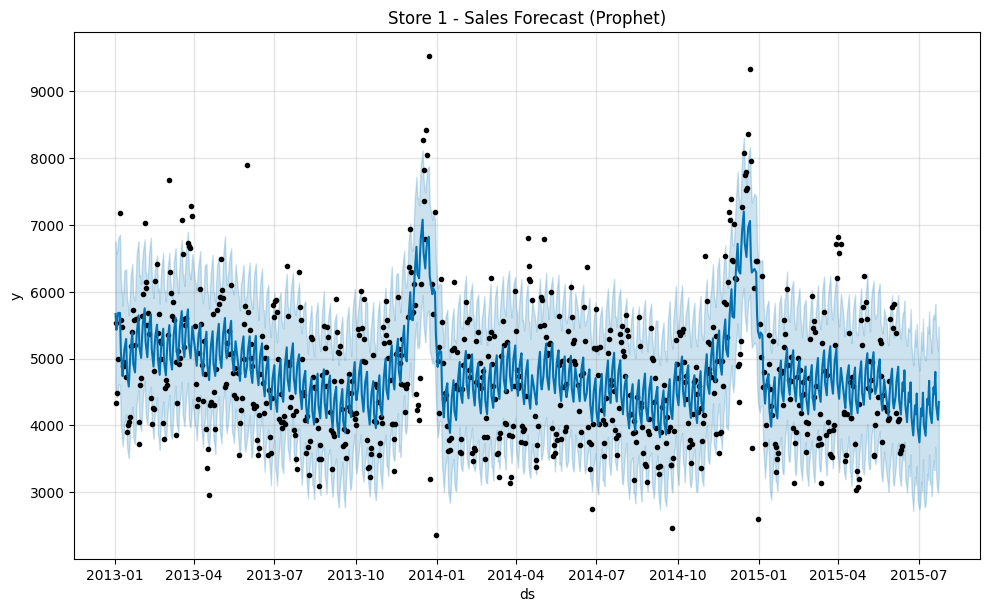

In [9]:
fig1 = model.plot(forecast)
plt.title(f"Store {store_id} - Sales Forecast (Prophet)")
plt.show()


In [10]:
pred = forecast.tail(42)["yhat"].values
true = test["y"].values

mae = mean_absolute_error(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 636.51
RMSE: 734.21


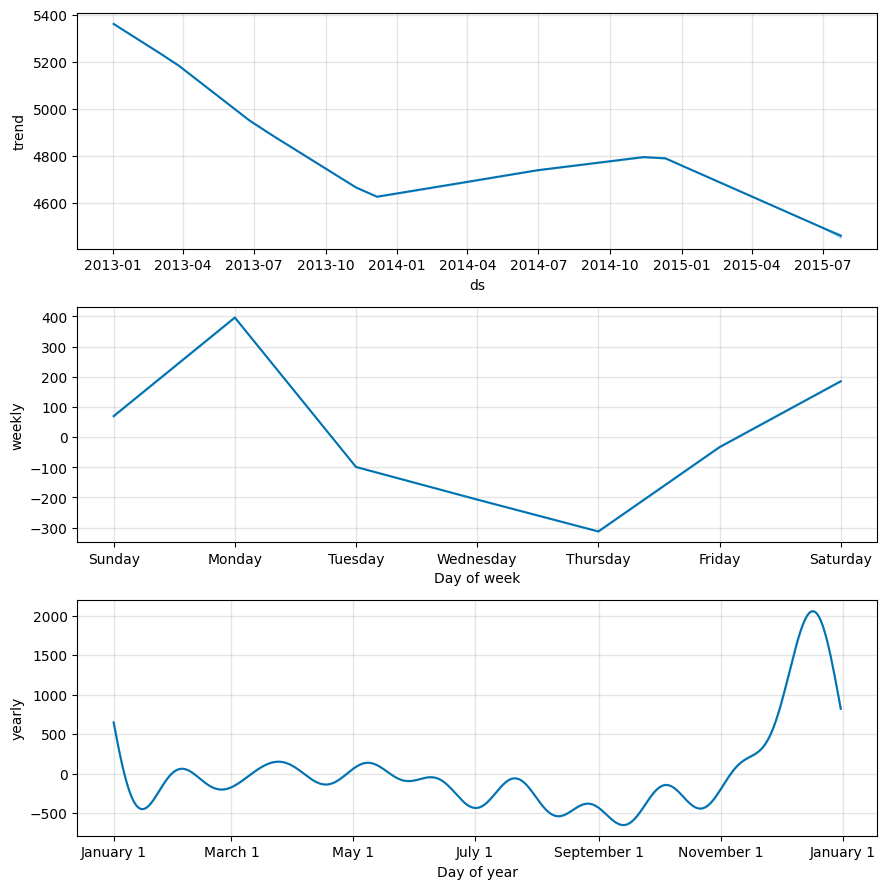

In [11]:
model.plot_components(forecast)
plt.show()


In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df = pd.read_csv("../data/train_processed.csv", parse_dates=["Date"])
print(df.shape)
df.head()


(1017209, 28)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,Day,WeekOfYear,DayOfYear,IsWeekend,Sales_lag_7,Sales_lag_30,Sales_roll_mean_7,Sales_roll_mean_30
0,1,2,2013-01-01,0,0,0,0,1,1,2,...,2013,1,1,1,1,0,0.0,0.0,0.0,0.0
1,1,3,2013-01-02,5530,668,1,0,0,1,2,...,2013,1,2,1,2,0,0.0,0.0,0.0,0.0
2,1,4,2013-01-03,4327,578,1,0,0,1,2,...,2013,1,3,1,3,0,0.0,0.0,0.0,0.0
3,1,5,2013-01-04,4486,619,1,0,0,1,2,...,2013,1,4,1,4,0,0.0,0.0,0.0,0.0
4,1,6,2013-01-05,4997,635,1,0,0,1,2,...,2013,1,5,1,5,1,0.0,0.0,0.0,0.0


In [14]:
target = "Sales"

features = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfYear', 'IsWeekend',
    'Sales_lag_7', 'Sales_lag_30', 'Sales_roll_mean_7', 'Sales_roll_mean_30'
]

X = df[features]
y = df[target]


In [15]:
train_df = df[df["Date"] < "2015-05-01"]
val_df = df[df["Date"] >= "2015-05-01"]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]

print(X_train.shape, X_val.shape)


(914629, 24) (102580, 24)


In [18]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


model = LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",
    n_estimators=500,
    num_leaves=64,
    learning_rate=0.05,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42
)


model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017945 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1982
[LightGBM] [Info] Number of data points in

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
MAE: 586.04
RMSE: 905.68


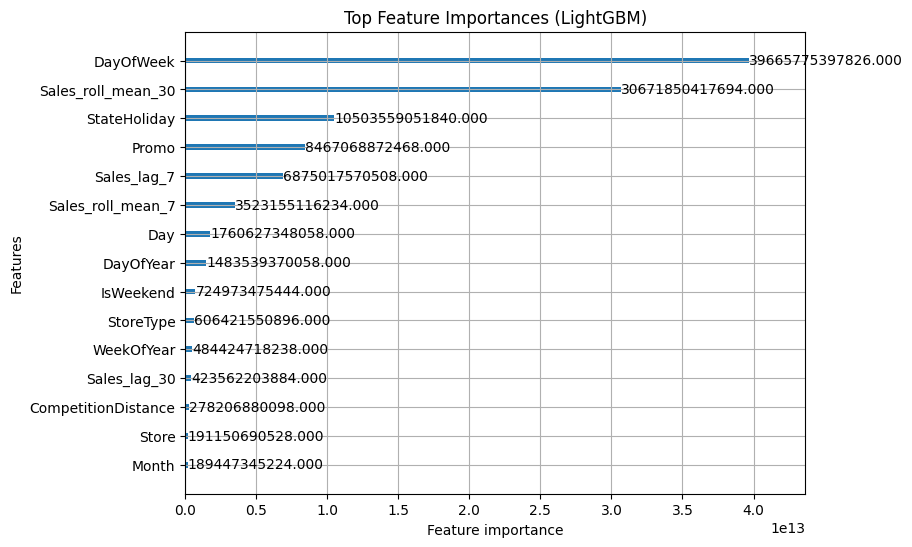

In [20]:
lgb.plot_importance(model, max_num_features=15, importance_type="gain", figsize=(8,6))
plt.title("Top Feature Importances (LightGBM)")
plt.show()


C:\Users\chait\AppData\Local\Temp\ipykernel_27476\1328278739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df["PredictedSales"] = y_pred


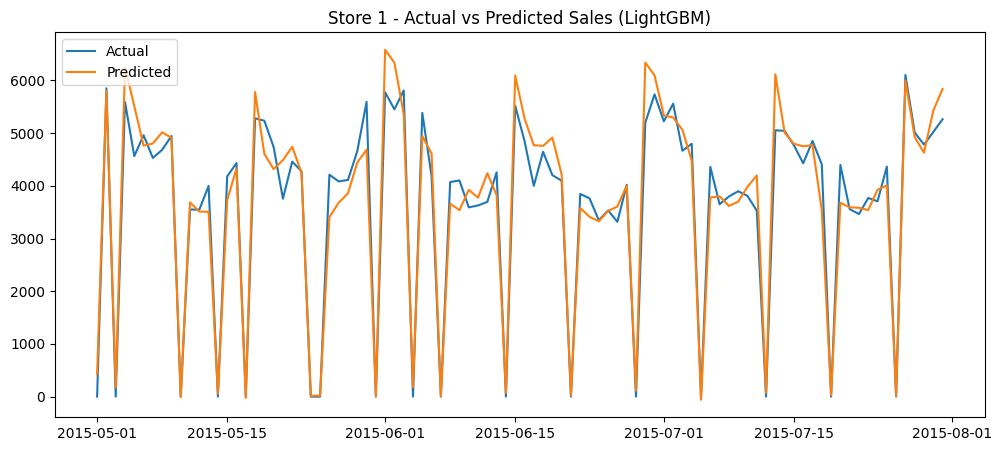

In [21]:
val_df["PredictedSales"] = y_pred
sample_store = val_df[val_df["Store"] == 1]

plt.figure(figsize=(12,5))
plt.plot(sample_store["Date"], sample_store["Sales"], label="Actual")
plt.plot(sample_store["Date"], sample_store["PredictedSales"], label="Predicted")
plt.title("Store 1 - Actual vs Predicted Sales (LightGBM)")
plt.legend()
plt.show()
